In [10]:
import pandas as pd

df = pd.read_csv("../data/processed/glucosa_data_limpio.csv")

print(df.head())
print(df.shape)

   Edad        IMC  Actividad_Fisica  Nivel_Glucosa
0    42  13.466414                 1     141.840332
1    67  23.455602                 1     171.937432
2    71  25.765184                 8     155.504232
3    48  24.079550                 2     115.865231
4    35  24.426649                 7     115.698730
(2000, 4)


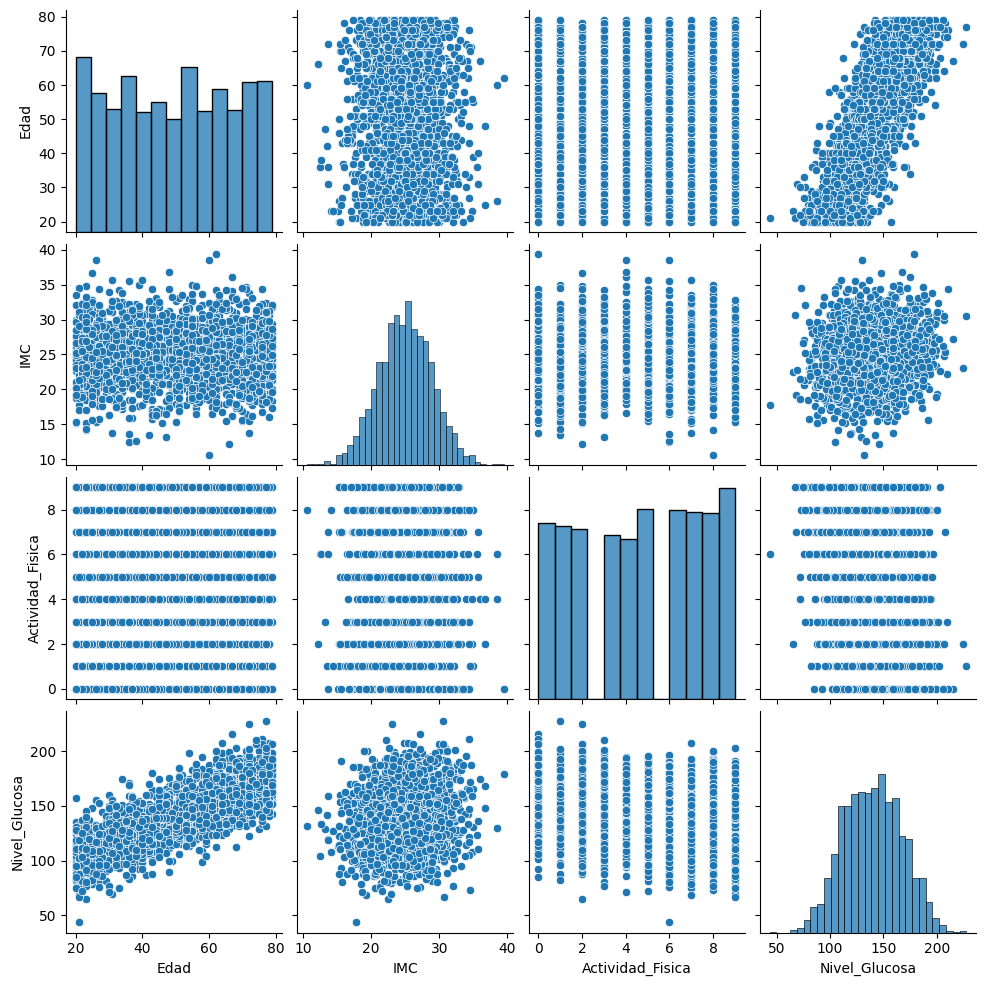

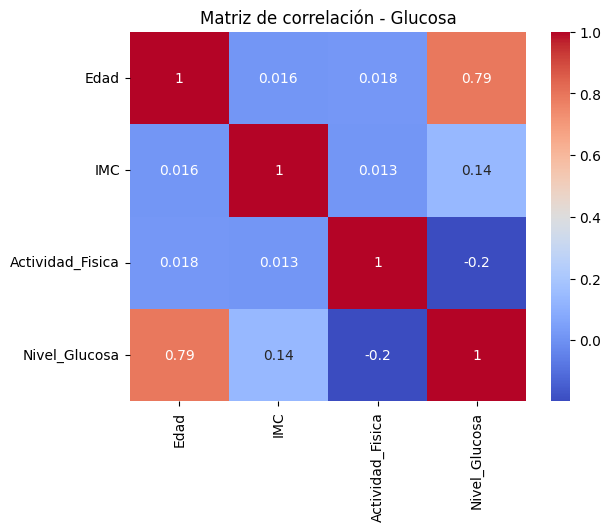

In [11]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.pairplot(df)
plt.show()

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Matriz de correlación - Glucosa")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Edad", "IMC", "Actividad_Fisica"]]
y = df["Nivel_Glucosa"]

X_train, X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model_glucosa = LinearRegression()
model_glucosa.fit(X_train,y_train)

y_pred = model_glucosa.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MSE:",mse)
print("R2:",r2)
print("R2 (%):",r2*100)

MSE: 233.69300045085828
R2: 0.681371586540484
R2 (%): 68.1371586540484


In [15]:
coef = pd.DataFrame(
    model_glucosa.coef_,
    X.columns,
    columns=["Impacto"]
)

print(coef.sort_values(by="Impacto",ascending=False))

                   Impacto
Edad              1.226590
IMC               0.933373
Actividad_Fisica -2.085276


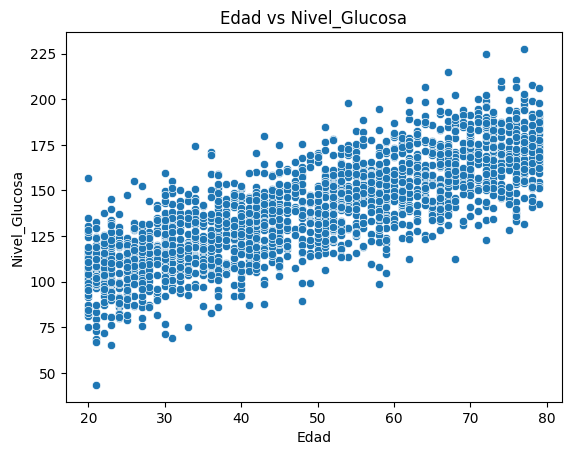

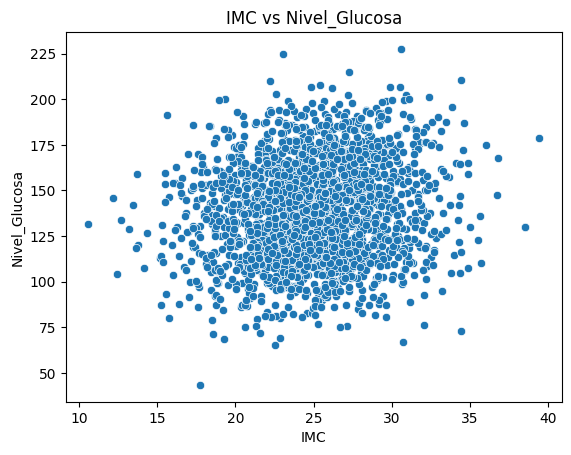

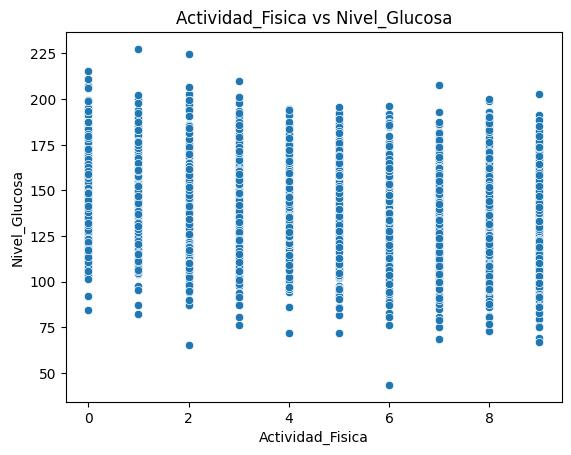

In [16]:
for col in X.columns:
    sns.scatterplot(x=df[col],y=df["Nivel_Glucosa"])
    plt.title(f"{col} vs Nivel_Glucosa")
    plt.show()

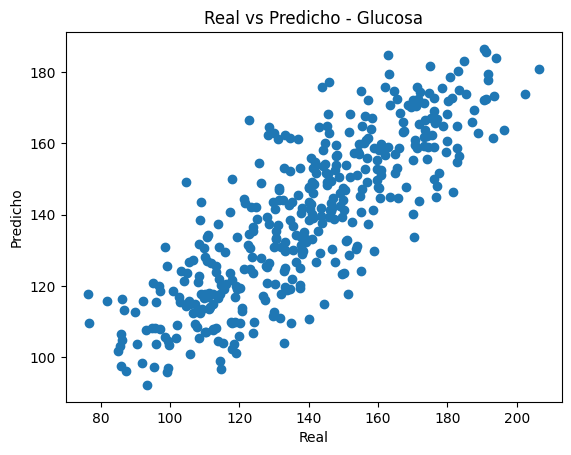

In [17]:
plt.scatter(y_test,y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho - Glucosa")
plt.show()